In [1]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
# -------------------------------
# Dataset
# -------------------------------
print("Loading Olivetti Faces dataset...")
faces = fetch_olivetti_faces()
X, y = faces.data, faces.target
print(f"Dataset shape: {X.shape}, Classes: {len(np.unique(y))}")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Loading Olivetti Faces dataset...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dataset shape: (400, 4096), Classes: 40


In [3]:
# -------------------------------
# PCA: Unsupervised Reduction
# -------------------------------
n_pca = 100
pca = PCA(n_components=n_pca, whiten=True, random_state=42)

t0 = time.time()
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
pca_time = time.time() - t0

In [4]:
# -------------------------------
# LDA: Supervised Reduction
# -------------------------------
lda = LinearDiscriminantAnalysis()

t1 = time.time()
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)
lda_time = time.time() - t1


In [5]:
# -------------------------------
# SVM Classification
# -------------------------------
clf_pca = SVC(kernel='linear', random_state=42)
clf_lda = SVC(kernel='linear', random_state=42)

clf_pca.fit(X_train_pca, y_train)
clf_lda.fit(X_train_lda, y_train)

y_pred_pca = clf_pca.predict(X_test_pca)
y_pred_lda = clf_lda.predict(X_test_lda)

acc_pca = accuracy_score(y_test, y_pred_pca)
acc_lda = accuracy_score(y_test, y_pred_lda)

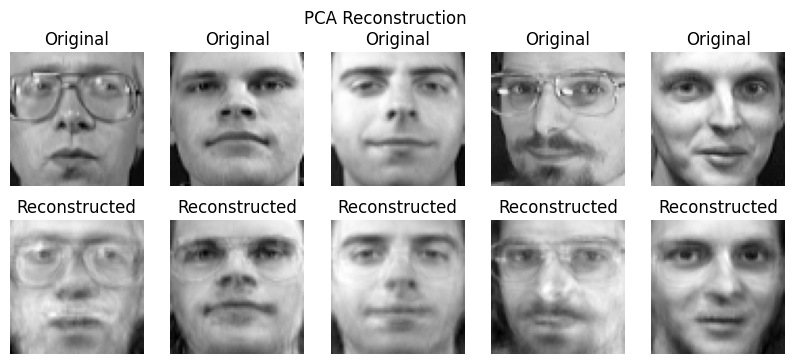

In [6]:
# -------------------------------
# PCA Reconstruction (Eigenfaces)
# -------------------------------
def reconstruct_images(pca, X_test, n=5):
    X_recon = pca.inverse_transform(pca.transform(X_test))
    fig, axes = plt.subplots(2, n, figsize=(10, 4))
    for i in range(n):
        axes[0, i].imshow(X_test[i].reshape(64, 64), cmap='gray')
        axes[0, i].set_title("Original")
        axes[1, i].imshow(X_recon[i].reshape(64, 64), cmap='gray')
        axes[1, i].set_title("Reconstructed")
        for ax in axes[:, i]: ax.axis("off")
    plt.suptitle("PCA Reconstruction")
    plt.show()

reconstruct_images(pca, X_test)

In [13]:
components = [10, 30, 50, 70]
for n in components:
    pca = PCA(n_components=n, whiten=True, random_state=42)
    X_recon = pca.inverse_transform(pca.fit_transform(X_test))
    mse = np.mean((X_test - X_recon)**2)
    print(f"Components={n}, Reconstruction Error={mse:.4f}")

Components=10, Reconstruction Error=0.0057
Components=30, Reconstruction Error=0.0021
Components=50, Reconstruction Error=0.0007
Components=70, Reconstruction Error=0.0001


Components=10, Reconstruction Error=0.0068
Components=30, Reconstruction Error=0.0041
Components=50, Reconstruction Error=0.0033
Components=80, Reconstruction Error=0.0028


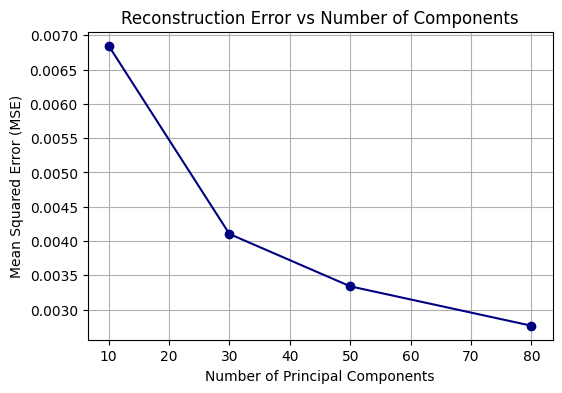

In [15]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


components = [10, 30, 50, 80]
errors = []


for n in components:
    pca = PCA(n_components=n, whiten=True, random_state=42)
    pca.fit(X_train)
    X_recon = pca.inverse_transform(pca.transform(X_test))
    mse = np.mean((X_test - X_recon)**2)
    errors.append(mse)
    print(f"Components={n}, Reconstruction Error={mse:.4f}")


plt.figure(figsize=(6,4))
plt.plot(components, errors, marker='o', color='navy')
plt.title("Reconstruction Error vs Number of Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

In [19]:
# -------------------------------
# Covariance Sharing Test: LDA vs QDA
# -------------------------------
qda = QuadraticDiscriminantAnalysis()

t2 = time.time()
qda.fit(X_train_pca, y_train)
y_pred_qda = qda.predict(X_test_pca)
qda_time = time.time() - t2
acc_qda = accuracy_score(y_test, y_pred_qda)
print(f"QDA Accuracy: {acc_qda:.4f}, Time: {qda_time:.4f}s")

QDA Accuracy: 0.0125, Time: 0.0234s


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p


=== Performance Summary ===
  Model  Accuracy  Time (s)      Components
0   PCA     0.975  1.010624             100
1   LDA     1.000  0.461915              39
2   QDA     0.025  0.031320  class-specific


/tmp/ipython-input-748371797.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='Accuracy', palette='coolwarm')


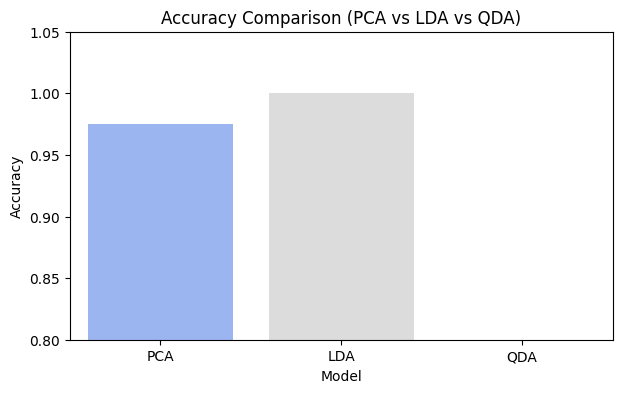

/tmp/ipython-input-748371797.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Model', y='Time (s)', palette='crest')


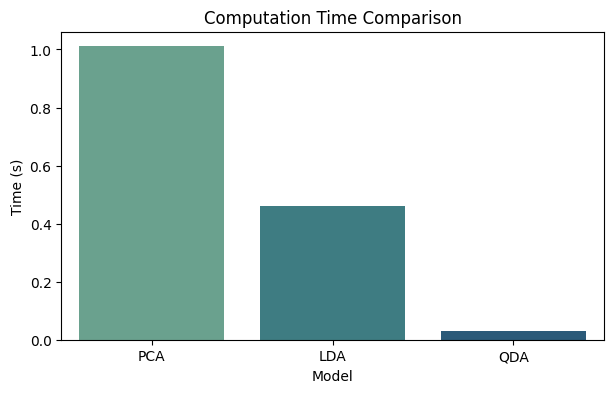

In [8]:
# -------------------------------
# Summary Table & Visualization
# -------------------------------
results = {
    'Model': ['PCA', 'LDA', 'QDA'],
    'Accuracy': [acc_pca, acc_lda, acc_qda],
    'Time (s)': [pca_time, lda_time, qda_time],
    'Components': [n_pca, X_train_lda.shape[1], 'class-specific']
}

import pandas as pd
df = pd.DataFrame(results)
print("\n=== Performance Summary ===")
print(df)

plt.figure(figsize=(7,4))
sns.barplot(data=df, x='Model', y='Accuracy', palette='coolwarm')
plt.title('Accuracy Comparison (PCA vs LDA vs QDA)')
plt.ylim(0.8, 1.05)
plt.show()

plt.figure(figsize=(7,4))
sns.barplot(data=df, x='Model', y='Time (s)', palette='crest')
plt.title('Computation Time Comparison')
plt.show()

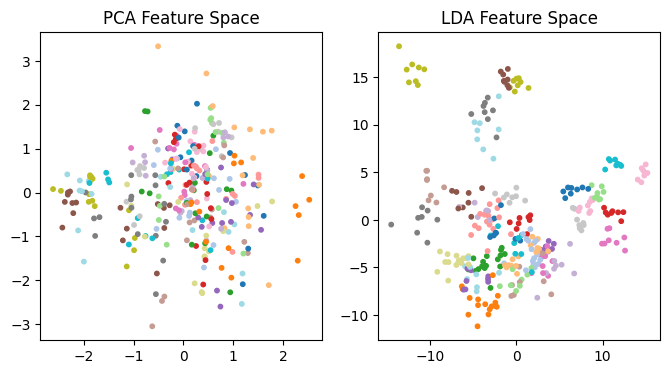

In [9]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='tab20', s=10)
plt.title("PCA Feature Space")

plt.subplot(1,2,2)
plt.scatter(X_train_lda[:,0], X_train_lda[:,1], c=y_train, cmap='tab20', s=10)
plt.title("LDA Feature Space")
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error
X_recon = pca.inverse_transform(pca.transform(X_test))
mse = mean_squared_error(X_test, X_recon)
print(f"PCA Reconstruction MSE: {mse:.6f}")

PCA Reconstruction MSE: 0.002510


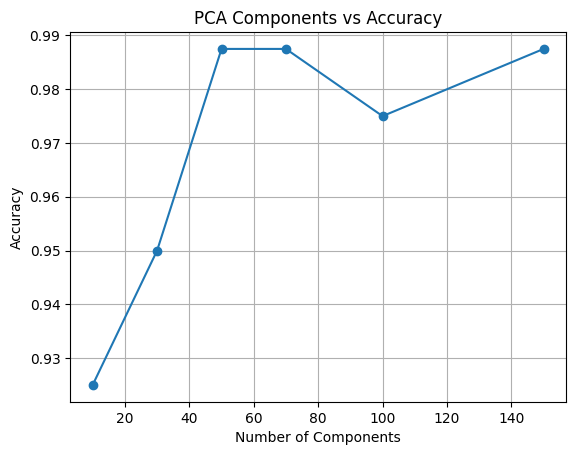

In [11]:
acc_list, dims = [], [10, 30, 50, 70, 100, 150]
for d in dims:
    pca = PCA(n_components=d, whiten=True, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    clf = SVC(kernel='linear')
    clf.fit(X_train_pca, y_train)
    acc_list.append(accuracy_score(y_test, clf.predict(X_test_pca)))

plt.plot(dims, acc_list, marker='o')
plt.title("PCA Components vs Accuracy")
plt.xlabel("Number of Components")
plt.ylabel("Accuracy")
plt.grid()
plt.show()